# Часть 1

---



Загружаем данные.

In [75]:
import pandas as pd
import numpy as np

In [76]:
df = pd.read_csv('enhanced_anxiety_dataset.csv')
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


## Описание датасета

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

**Краткая информация:** Данный датасет показывает комплексную картину факторов, связанных с социальной тревожностью, демонстрируя, как образ жизни, физиологические показатели и психологический фон влияют на уровень тревожности человека

**Размерность:** 11 000 строк (объектов) × 19 столбцов (признаков)

**Пропущенные значения:** Отсутствуют

| Признак | Описание | Тип признака |
|---------|----------|--------------|
| **Age** | Возраст (в годах) | Метрический |
| **Gender** | Пол: "Male" (мужской), "Female" (женский), "Other" (другой) | Категориальный (номинальный) |
| **Occupation** | Род занятий: например, "Artist" (художник), "Nurse" (медсестра), "Lawyer" (юрист) и др. | Категориальный (номинальный) |
| **Sleep Hours** | Средняя продолжительность сна (часов в сутки) | Метрический |
| **Physical Activity (hrs/week)** | Уровень физической активности (часов в неделю) | Метрический |
| **Caffeine Intake (mg/day)** | Суточное потребление кофеина (мг/день) | Метрический |
| **Alcohol Consumption (drinks/week)** | Потребление алкоголя (порций в неделю) | Метрический |
| **Smoking** | Наличие привычки курения: "Yes" (да), "No" (нет) | Категориальный (бинарный) |
| **Family History of Anxiety** | Тревожность в семейном анамнезе: "Yes" (да), "No" (нет) | Категориальный (бинарный) |
| **Stress Level (1-10)** | Уровень стресса по шкале от 1 (минимальный) до 10 (максимальный) | Категориальный (порядковый) |
| **Heart Rate (bpm)** | Частота сердечных сокращений (ударов в минуту) | Метрический |
| **Breathing Rate (breaths/min)** | Частота дыхания (вдохов-выдохов в минуту) | Метрический |
| **Sweating Level (1-5)** | Интенсивность потоотделения по шкале от 1 (минимальная) до 5 (максимальная) | Категориальный (порядковый) |
| **Dizziness** | Наличие эпизодов головокружения: "Yes" (да), "No" (нет) | Категориальный (бинарный) |
| **Medication** | Прием лекарственных препаратов: "Yes" (да), "No" (нет) | Категориальный (бинарный) |
| **Therapy Sessions (per month)** | Частота посещения психотерапевта (сессий в месяц) | Метрический |
| **Recent Major Life Event** | Наличие серьезных жизненных изменений в недавнем прошлом: "Yes" (да), "No" (нет) | Категориальный (бинарный) |
| **Diet Quality (1-10)** | Качество питания по шкале от 1 (нездоровое) до 10 (здоровое) | Категориальный (порядковый) |
| **Anxiety Level (1-10)** | Итоговый уровень социальной тревожности по шкале от 1 (минимальный) до 10 (максимальный) | Категориальный (порядковый) |

## Подготовка данных к анализу

In [78]:
# Узнаем, сколько уникальных значений в столбце 'Gender'
# Если занчений немного -> преобразуем столбец из object в category
df['Gender'].unique()

array(['Female', 'Other', 'Male'], dtype=object)

In [79]:
# Преобразовываем 'Gender' в category
df['Gender'] = pd.Categorical(df['Gender'], ordered=False)

In [80]:
# Преобразовываем категориальные (бинарные) переменные из object в int
df['Smoking'] = df['Smoking'].map({'Yes': 1, 'No': 0})
df['Family History of Anxiety'] = df['Family History of Anxiety'].map({'Yes': 1, 'No': 0})
df['Dizziness'] = df['Dizziness'].map({'Yes': 1, 'No': 0})
df['Medication'] = df['Medication'].map({'Yes': 1, 'No': 0})
df['Recent Major Life Event'] = df['Recent Major Life Event'].map({'Yes': 1, 'No': 0})

Перекодируем метрический столбец 'Age' в категориальный. Возрастные границы выбраны в соответствии с общепринятой классификацией возрастных периодов Всемирной организации здравоохранения (ВОЗ):

*   до 18 — дети/подростки
*   18-44 лет — молодые люди
*   45-59 — взрослые
*   от 60 — пожилые






In [81]:
# Функция для разбиения возраста на группы
def get_age_group(x):
    if x < 18:
        return 'Children/teenagers'
    elif x >= 18 and x < 45:
        return 'Young people'
    elif x >= 45 and x < 60:
        return 'Adults'
    elif x >= 60:
        return 'Elderly people'

In [82]:
df['Age'] = df['Age'].apply(get_age_group)
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,Young people,Female,Artist,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7,5.0
1,Adults,Other,Nurse,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8,3.0
2,Elderly people,Male,Other,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1,1.0
3,Young people,Female,Scientist,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1,2.0
4,Adults,Female,Other,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3,1.0


Рассчитаем новый столбец, который определяет уровень образа жизни. Образ жизни считается здоровым (Healthy), если сумма баллов составляет 3 и более по пяти критериям:  продолжительность сна (7–9 часов), физическая активность (не менее 2.5 часов в неделю), качество питания (оценка от 7 и выше), отсутствие курения и умеренное потребление алкоголя (не более 5 порций в неделю) — в противном случае нездоровым (Unhealthy).

In [83]:
# Функция определяет уровень жизни
def calculate_lifestyle_score(x):
  score = 0
  if 7 <= x['Sleep Hours'] <= 9:
    score += 1
  if x['Physical Activity (hrs/week)'] >= 2.5:
    score += 1
  if x['Diet Quality (1-10)'] >= 7:
    score += 1
  if x['Smoking'] == 0:
    score += 1
  if x['Alcohol Consumption (drinks/week)'] <= 5:
    score += 1
  if score >= 3:
    return 'Healthy'
  else:
    return 'Unhealthy'

In [84]:
df['Lifestyle Score'] = df.apply(calculate_lifestyle_score, axis=1)
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Lifestyle Score
0,Young people,Female,Artist,6.0,2.7,181,10,1,0,10,114,14,4,0,1,3,1,7,5.0,Unhealthy
1,Adults,Other,Nurse,6.2,5.7,200,8,1,1,1,62,23,2,1,0,2,0,8,3.0,Unhealthy
2,Elderly people,Male,Other,5.0,3.7,117,4,0,1,1,91,28,3,0,0,1,1,1,1.0,Healthy
3,Young people,Female,Scientist,5.8,2.8,360,6,1,0,4,86,17,3,0,0,0,0,1,2.0,Unhealthy
4,Adults,Female,Other,8.2,2.3,247,4,1,0,1,98,19,4,1,1,1,0,3,1.0,Unhealthy


## Цель, задачи, гипотезы исследования

Целью данного исследовательского проекта является комплексный анализ факторов, влияющих на уровень социальной тревожности у людей, на основе набора данных, включающего демографические, поведенческие, физиологические и психологические характеристики.

Задачи:


1.   Написать 10+ гипотез
2.   Определить методы проверки гипотез, распределить их на группы по методу исследования
3.   Построить 5+ графиков
4.   Построить 3 сводные таблицы
5.   Провести тест Хи-квадрат
6.   Рассчитать описательные статистики
7.   Посчитать корреляции между числовыми данными
8.   Построить модель линейной регрессии
9.   Построить модель бинарной регрессии
10.  Провести кластерный анализ данных
11.  Сделать выводы по гипотезам (подтверждены/отвергнуты)
12.  Сформулировать общие выводы по результатам анализа






Гипотезы:

**Гипотеза 1: Уровень тревожности выше у людей с низким качеством сна.**

H0: Нет значимой корреляции между продолжительностью сна ('Sleep Hours') и уровнем тревожности ('Anxiety Level (1-10)').

H1: Существует отрицательная корреляция между продолжительностью сна ('Sleep Hours') и уровнем тревожности ('Anxiety Level (1-10)').

**Гипотеза 2: Женщины имеют более высокий уровень тревожности, чем мужчины.**

H0: Нет значимой разницы в уровне тревожности ('Anxiety Level (1-10)') между полами ('Gender').

H1: Уровень тревожности ('Anxiety Level (1-10)') выше у женщин ('Female') по сравнению с мужчинами ('Male').

**Гипотеза 3: Физическая активность снижает уровень тревожности.**

H0: Нет значимой корреляции между физической активностью ('Physical Activity (hrs/week)') и уровнем тревожности ('Anxiety Level (1-10)').

H1: Существует отрицательная корреляция между физической активностью ('Physical Activity (hrs/week)') и уровнем тревожности ('Anxiety Level (1-10)').

**Гипотеза 4: Курение ассоциировано с более высоким уровнем тревожности.**

H0: Нет связи между курением ('Smoking') и уровнем тревожности ('Anxiety Level (1-10)').

H1: Курящие имеют более высокий уровень тревожности ('Anxiety Level (1-10)').

**Гипотеза 5: Семейная история тревожности повышает риск высокого уровня тревожности.**

H0: Нет связи между семейной историей ('Family History of Anxiety') и уровнем тревожности ('Anxiety Level (1-10)').

H1: Люди с семейной историей тревожности имеют более высокий уровень тревожности ('Anxiety Level (1-10)').

**Гипотеза 6: Высокий уровень стресса связан с повышенной частотой сердцебиения.**

H0: Нет корреляции между стрессом ('Stress Level (1-10)') и частотой сердцебиения ('Heart Rate (bpm)').

H1: Существует положительная корреляция.

**Гипотеза 7: Недавние события в жизни повышают уровень тревожности.**

H0: Нет разницы в уровне тревожности ('Anxiety Level (1-10)') между группами с недавними важными событиями и без них ('Recent Major Life Event').

H1: Люди с недавними событиями имеют более высокий уровень тревожности ('Anxiety Level (1-10)').

**Гипотеза 8: Качество питания влияет на уровень тревожности.**

H0: Нет корреляции между качеством питания ('Diet Quality (1-10)') и тревожностью ('Anxiety Level (1-10)').

H1: Более высокое качество питания ('Diet Quality (1-10)') ассоциировано с более низким уровнем тревожности ('Anxiety Level (1-10)').

**Гипотеза 9: Потребление кофеина повышает физиологические показатели тревожности.**

H0: Нет корреляции между кофеином ('Caffeine Intake (mg/day)') и физиологическими показатели тревожности, такими как дыхание ('Breathing Rate (breaths/min)'), частота сердцебиения ('Heart Rate (bpm)'), уровнь потливости ('Sweating Level (1-5)').

H1: Существует положительная корреляция.

**Гипотеза 10: Люди с нездоровым образом жизни склонны к высокой тревожности.**

H0: Нет значимых кластеров на основе образа жизни ('Lifestyle Score') и уровня тревожности ('Anxiety Level (1-10)').

H1: Существуют кластеры, где нездоровый образ жизни ('Unhealthy') ассоциирован с высокой тревожностью ('Anxiety Level (1-10)').

**Гипотеза 11: Возрастная группа влияет на уровень тревожности.**

H0: Нет разницы в уровне тревожности ('Anxiety Level (1-10)') между возрастными группами ('Age').

H1: Молодые люди ('Young people') имеют более высокий уровень тревожности ('Anxiety Level (1-10)').


Для начала проанализируем распределение уровня тревожности и определим его наиболее часто встречающееся значение.

<Axes: xlabel='Anxiety Level (1-10)'>

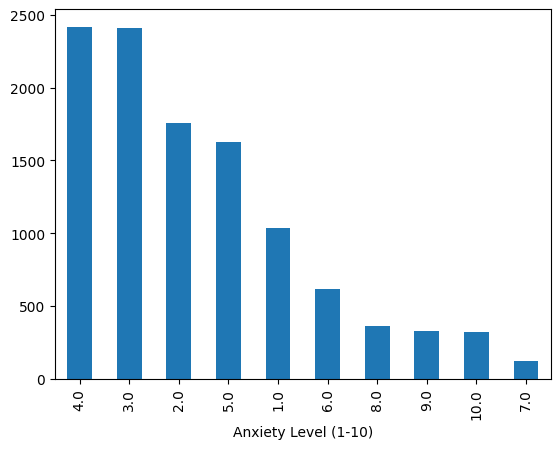

In [85]:
df['Anxiety Level (1-10)'].value_counts().plot.bar()

График наглядно показывает, что пиковыми значениями являются 3 и 4 (наибольшая частота встречаемости), наименее распространенным — значение 7. Доля людей с высоким (8) и крайне высоким (9–10) уровнями тревожности также минимальна.

## Корреляционный анализ

Для исследования гипотез 1, 3, 6, 8, 9 были выбраны методы корреляционного анализа, так как все эти гипотезы направлены на выявление наличия, силы и направления связи между двумя переменными.

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

### Гипотеза 1

Признаки: Anxiety Level (1-10), Sleep Hours

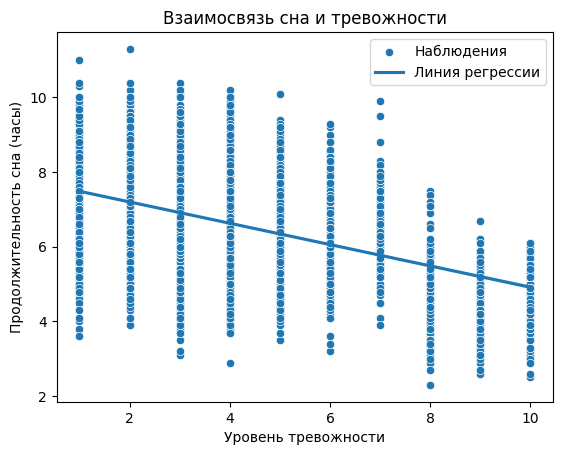

In [87]:
sns.scatterplot(data=df, x='Anxiety Level (1-10)', y='Sleep Hours', label='Наблюдения')
sns.regplot(data=df, x='Anxiety Level (1-10)', y='Sleep Hours', scatter=False, label='Линия регрессии')
plt.title('Взаимосвязь сна и тревожности')
plt.xlabel('Уровень тревожности')
plt.ylabel('Продолжительность сна (часы)')
plt.legend()
plt.show()

Линия регрессии на графике наглядно демонстрирует обратную зависимость: с ростом уровня тревожности продолжительность сна снижается. При критических значениях тревожности (8–10 баллов) отсутствуют наблюдения с продолжительностью сна более 8 часов. И напротив, при минимальном уровне тревожности (1–2 балла) фиксируются случаи, где продолжительность сна превышает 10 часов.

In [88]:
print('r:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Sleep Hours'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Sleep Hours'].dropna())[1])

r: -0.4938360295020115      p-value: 0.0


Обнаружена слабая отрицательная корреляция между продолжительностью сна и уровнем тревожности (r = -0.49), что подтверждается графиком. Связь статистически значима (p < 0.05). Таким образом, гипотеза Н1 подтвердилась.

### Гипотеза 3

Признаки: Anxiety Level (1-10), Physical Activity (hrs/week)

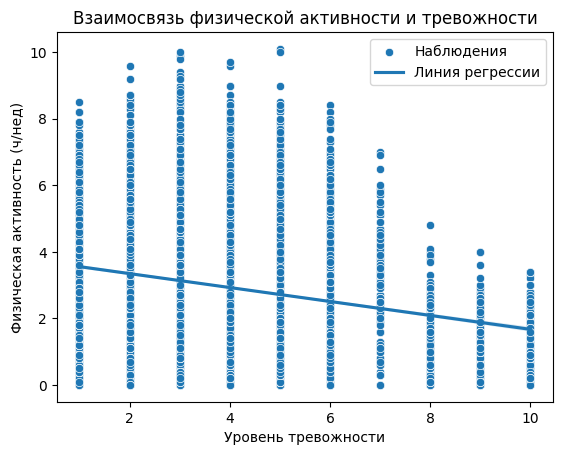

In [89]:
sns.scatterplot(data=df, x='Anxiety Level (1-10)', y='Physical Activity (hrs/week)', label='Наблюдения')
sns.regplot(data=df, x='Anxiety Level (1-10)', y='Physical Activity (hrs/week)', scatter=False, label='Линия регрессии')
plt.title('Взаимосвязь физической активности и тревожности')
plt.xlabel('Уровень тревожности')
plt.ylabel('Физическая активность (ч/нед)')
plt.legend()
plt.show()

График показывает отрицательную корреляцию: с ростом уровня тревожности физическая активность имеет тенденцию к снижению. При критических значениях тревожности ее уровень не превышает 5 часов в неделю. Наибольшие показатели активности приходятся на диапазон умеренной тревожности (3–5 баллов).

In [90]:
print('r:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Physical Activity (hrs/week)'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Physical Activity (hrs/week)'].dropna())[1])

r: -0.24318696994340483      p-value: 8.108838280993203e-148


Между уровнем тревожности и физической активностью обнаружена очень слабая отрицательная корреляционная связь (r = -0.24). Результат статистически значим p-value < 0.05, гипотеза H1 подтвердилась.

### Гипотеза 6

Признаки: Stress Level (1-10), Heart Rate (bpm)

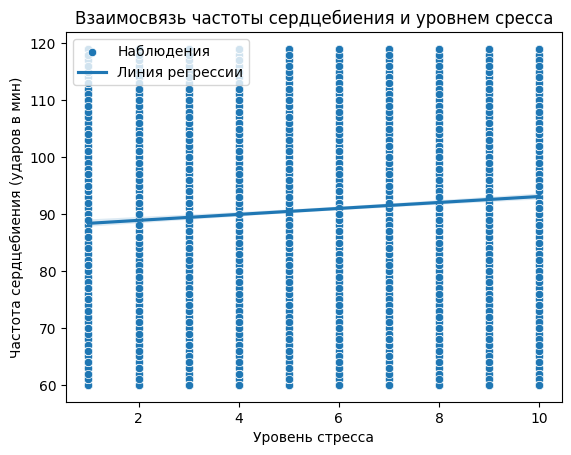

In [91]:
sns.scatterplot(data=df, x='Stress Level (1-10)', y='Heart Rate (bpm)', label='Наблюдения')
sns.regplot(data=df, x='Stress Level (1-10)', y='Heart Rate (bpm)', scatter=False, label='Линия регрессии')
plt.title('Взаимосвязь частоты сердцебиения и уровнем сресса')
plt.xlabel('Уровень стресса')
plt.ylabel('Частота сердцебиения (ударов в мин)')
plt.legend()
plt.show()

Линия регрессии демонстрирует незначительное учащение пульса при повышении уровня стресса, однако малый угол наклона свидетельствует о крайне слабой связи между показателями.

In [92]:
print('r:', stats.spearmanr(df['Stress Level (1-10)'].dropna(), df['Heart Rate (bpm)'].dropna())[0],
      '     p-value:', stats.spearmanr(df['Stress Level (1-10)'].dropna(), df['Heart Rate (bpm)'].dropna())[1])

r: 0.08934013256050605      p-value: 6.127596586897027e-21


Между уровнем стресса и частотой сердечных сокращений наблюдается очень слабая положительная связь (r = 0.09). При этом p-value < 0.05 указывает на то, что даже такая слабая связь является статистически значимой, а занчит гипотеза H0 опровергается.

### Гипотеза 8

Признаки: Anxiety Level (1-10), Diet Quality (1-10)

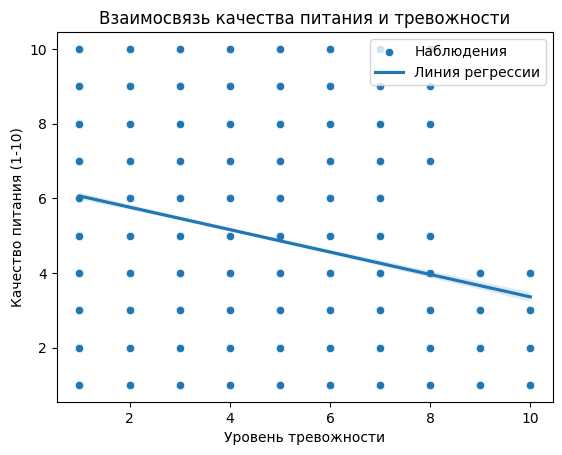

In [93]:
sns.scatterplot(data=df, x='Anxiety Level (1-10)', y='Diet Quality (1-10)', label='Наблюдения')
sns.regplot(data=df, x='Anxiety Level (1-10)', y='Diet Quality (1-10)', scatter=False, label='Линия регрессии')
plt.title('Взаимосвязь качества питания и тревожности')
plt.xlabel('Уровень тревожности')
plt.ylabel('Качество питания (1-10)')
plt.legend()
plt.show()

На графике прослеживается слабый нисходящий тренд линии регрессии, что свидетельствует об отрицательной связи между качеством питания и уровнем тревожности. Характер распределения наблюдений указывает на нелинейность зависимости: при максимальных значениях тревожности (9–10 баллов) качество питания не превышает 4 баллов, однако при высоком уровне тревоги (8 баллов) фиксируются случаи с высоким качеством питания.

In [94]:
print('r:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Diet Quality (1-10)'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Anxiety Level (1-10)'].dropna(), df['Diet Quality (1-10)'].dropna())[1])

r: -0.22024523699925946      p-value: 6.131352938981384e-121


Между качеством питания и уровнем тревожности обнаружена слабая отрицательная связь (ρ = -0.22). Направление связи соответствует гипотезе H1: более высокое качество питания ассоциировано с более низким уровнем тревожности. Значение p-value < 0.05, что говорит о статистической значимости связи.

### Гипотеза 9

Признаки: Caffeine Intake (mg/day), Breathing Rate (breaths/min), Heart Rate (bpm), Sweating Level (1-5)

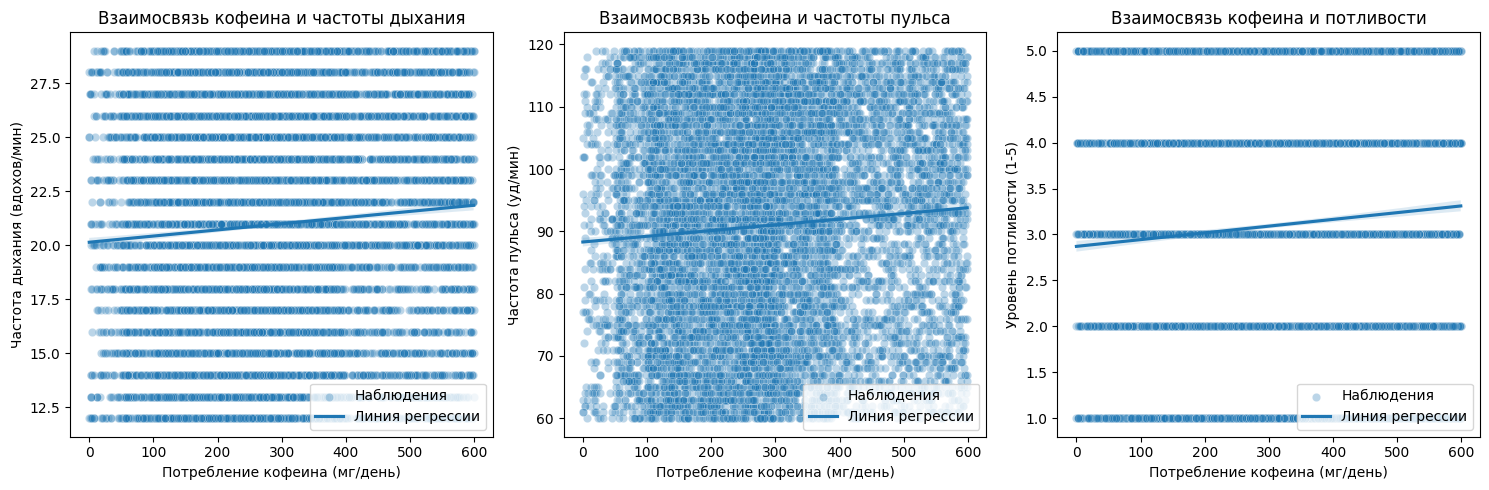

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Кофеин и частота дыхания
sns.scatterplot(data=df, x='Caffeine Intake (mg/day)', y='Breathing Rate (breaths/min)',
                ax=axes[0], alpha=0.3, label='Наблюдения')
sns.regplot(data=df, x='Caffeine Intake (mg/day)', y='Breathing Rate (breaths/min)',
            scatter=False, ax=axes[0], label='Линия регрессии')
axes[0].set_title('Взаимосвязь кофеина и частоты дыхания')
axes[0].set_xlabel('Потребление кофеина (мг/день)')
axes[0].set_ylabel('Частота дыхания (вдохов/мин)')
axes[0].legend()

# График 2: Кофеин и пульс
sns.scatterplot(data=df, x='Caffeine Intake (mg/day)', y='Heart Rate (bpm)',
                ax=axes[1], alpha=0.3, label='Наблюдения')
sns.regplot(data=df, x='Caffeine Intake (mg/day)', y='Heart Rate (bpm)',
            scatter=False, ax=axes[1], label='Линия регрессии')
axes[1].set_title('Взаимосвязь кофеина и частоты пульса')
axes[1].set_xlabel('Потребление кофеина (мг/день)')
axes[1].set_ylabel('Частота пульса (уд/мин)')
axes[1].legend()

# График 3: Кофеин и потливость
sns.scatterplot(data=df, x='Caffeine Intake (mg/day)', y='Sweating Level (1-5)',
                ax=axes[2], alpha=0.3, label='Наблюдения')
sns.regplot(data=df, x='Caffeine Intake (mg/day)', y='Sweating Level (1-5)',
            scatter=False, ax=axes[2], label='Линия регрессии')
axes[2].set_title('Взаимосвязь кофеина и потливости')
axes[2].set_xlabel('Потребление кофеина (мг/день)')
axes[2].set_ylabel('Уровень потливости (1-5)')
axes[2].legend()

plt.tight_layout()
plt.show()

На всех трех графиках наблюдается схожая картина: между потреблением кофеина и физиологическими показателями (частотой дыхания, частотой пульса и уровнем потливости) прослеживается очень слабая положительная связь. Линии регрессии имеют незначительный подъем, а точки образуют широкую область рассеяния без четко выраженного тренда.

In [96]:
print('r:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Heart Rate (bpm)'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Heart Rate (bpm)'].dropna())[1])
print('r:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Breathing Rate (breaths/min)'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Breathing Rate (breaths/min)'].dropna())[1])
print('r:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Sweating Level (1-5)'].dropna())[0],
      '     p-value:', stats.pearsonr(df['Caffeine Intake (mg/day)'].dropna(), df['Sweating Level (1-5)'].dropna())[1])

r: 0.07655450260264772      p-value: 8.984463826676863e-16
r: 0.07999994312135102      p-value: 4.3528386054887627e-17
r: 0.07601084971615273      p-value: 1.4313276482142873e-15


Между потреблением кофеина (Caffeine Intake) и частотой дыхания (Breathing Rate) обнаружена очень слабая положительная корреляционная связь (r = 0.08). Аналогично слабые положительные связи наблюдаются между кофеином и частотой сердцебиения (Heart Rate, r = 0.08), а также между кофеином и уровнем потливости (Sweating Level, r = 0.08). Несмотря на низкую силу связи, все полученные результаты являются статистически значимыми (p < 0.05), гипотеза H1 истина.

## Mодель линейной регрессии

Для количественной оценки влияния различных факторов (количество часов сна, физическая активность, употребления алкоголя, кофеина, уровень стресса и качество диеты) на уровень тревожности построим модель множественной линейной регрессии. Модель позволит определить, какие именно признаки вносят наибольший вклад в изменение целевой переменной, и оценить силу этого влияния.

In [97]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [98]:
df[['Sleep Hours', 'Physical Activity (hrs/week)',
    'Alcohol Consumption (drinks/week)', 'Caffeine Intake (mg/day)',
    'Diet Quality (1-10)', 'Stress Level (1-10)']].corr()

,Sleep Hours,Physical Activity (hrs/week),Alcohol Consumption (drinks/week),Caffeine Intake (mg/day),Diet Quality (1-10),Stress Level (1-10)
Sleep Hours,1.000000,0.174526,-0.068068,-0.208659,0.154110,-0.177315
Physical Activity (hrs/week),0.174526,1.000000,-0.032936,-0.115298,0.085587,-0.103475
Alcohol Consumption (drinks/week),-0.068068,-0.032936,1.000000,0.036401,-0.029601,0.051508
Caffeine Intake (mg/day),-0.208659,-0.115298,0.036401,1.000000,-0.089457,0.121424
Diet Quality (1-10),0.154110,0.085587,-0.029601,-0.089457,1.000000,-0.110085
Stress Level (1-10),-0.177315,-0.103475,0.051508,0.121424,-0.110085,1.000000


Сильной корреляции между предикторами не наблюдается.

In [99]:
df_model1 = df.dropna(subset=['Anxiety Level (1-10)', 'Sleep Hours',
                              'Physical Activity (hrs/week)', 'Alcohol Consumption (drinks/week)',
                              'Caffeine Intake (mg/day)','Diet Quality (1-10)',
                              'Stress Level (1-10)'])
df_model1.shape

(11000, 20)

In [100]:
x = df_model1[['Sleep Hours', 'Physical Activity (hrs/week)',
              'Alcohol Consumption (drinks/week)','Caffeine Intake (mg/day)',
              'Diet Quality (1-10)', 'Stress Level (1-10)']]
y = df_model1['Anxiety Level (1-10)']
x_const = sm.add_constant(x)
model1 = sm.OLS(y, x_const).fit()
print(model1.summary())

                             OLS Regression Results                             
Dep. Variable:     Anxiety Level (1-10)   R-squared:                       0.651
Model:                              OLS   Adj. R-squared:                  0.650
Method:                   Least Squares   F-statistic:                     3410.
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          20:14:58   Log-Likelihood:                -18105.
No. Observations:                 11000   AIC:                         3.622e+04
Df Residuals:                     10993   BIC:                         3.627e+04
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [101]:
print('R^2 = {:f}'.format(model1.rsquared))
print('F-test significance = {:f}'.format(model1.f_pvalue))

R^2 = 0.650507
F-test significance = 0.000000


Модель статистически значима. Объясняет 65% вариации значений зависимой переменной.

In [102]:
true_values = df_model1['Anxiety Level (1-10)']
predicted_values = model1.fittedvalues
mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

true_values = df_model1['Anxiety Level (1-10)']
predicted_values =  model1.fittedvalues
mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

true_values = df_model1['Anxiety Level (1-10)']
predicted_values =  model1.fittedvalues
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Mean Absolute Error: 0.9987126773667807
Mean Squared Error: 1.5743731010785658
Root Mean Squared Error (RMSE): 1.2547402524341704


In [103]:
f'Статистически значимые параметры модели: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Статистически значимые параметры модели: ['const' 'Sleep Hours' 'Physical Activity (hrs/week)'\n 'Alcohol Consumption (drinks/week)' 'Caffeine Intake (mg/day)'\n 'Diet Quality (1-10)' 'Stress Level (1-10)']"

In [104]:
f'Статистически не значимые параметры модели: {model1.pvalues[model1.pvalues > 0.05].index.values}'

'Статистически не значимые параметры модели: []'

In [105]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('Y = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

Y = 4.903237 + -0.55*Sleep Hours + -0.11*Physical Activity (hrs/week) + 0.01*Alcohol Consumption (drinks/week) + 0.00*Caffeine Intake (mg/day) + -0.06*Diet Quality (1-10) + 0.41*Stress Level (1-10)


/tmp/ipykernel_10006/2146136170.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Y = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))


Детальная интерпретация модели:

Увеличение продолжительности сна на 1 час в сутки снижает уровень тревожности в среднем на 0.55 балла при неизменных значениях остальных факторов.

Каждый дополнительный час физической активности в неделю снижает уровень тревожности в среднем на 0.11 балла.

Каждая дополнительная порция алкоголя в неделю повышает уровень тревожности в среднем на 0.01 балла.

Увеличение потребления кофеина на 100 мг в день повышает уровень тревожности в среднем на 0.29 балла.

Повышение качества питания на 1 балл снижает уровень тревожности в среднем на 0.06 балла.

Увеличение уровня стресса на 1 балл повышает уровень тревожности в среднем на 0.41 балла. Это самый сильный предиктор среди всех включенных факторов.

Таким образом, результаты регрессионного анализа согласуются с выводами корреляционного анализа и подтверждают, что ключевыми факторами, связанными с уровнем тревожности, являются качество сна, а также стресс (что логично), тогда как поведенческие факторы (питание, активность) играют менее значимую роль.

## Сводные таблицы и Хи-квадрат

In [106]:
from scipy import stats

Для проверки гипотез 4, 5 и 7 были выбраны методы построения сводных таблиц и критерий (Хи-квадрат). Данный выбор обусловлен типом данных: все независимые переменные (Smoking, Family History of Anxiety, Recent Major Life Event) являются бинарными категориальными, а зависимая переменная (Anxiety Level) позволяет построить таблицы сопряженности. Сводные таблицы необходимы для наглядного сравнения средних значений и распределений уровня тревожности в выделенных группах. Критерий Хи-квадрат, в свою очередь, позволяет определить, являются ли наблюдаемые различия между группами статистически значимыми, и проверить нулевую гипотезу об отсутствии связи между факторами и уровнем тревожности.

### Гипотеза 4

Признаки: Anxiety Level (1-10), Smoking

In [107]:
pd.pivot_table(df, values='Anxiety Level (1-10)', index='Smoking', aggfunc={'Anxiety Level (1-10)': ['mean', 'median', 'std', 'min', 'max', 'count']})

,count,max,mean,median,min,std
Smoking,,,,,,
0,5221,10.0,3.74660,4.0,1.0,1.929890
1,5779,10.0,4.09448,4.0,1.0,2.270189


Согласно сводной таблице, средний уровень тревожности у курящих респондентов (4.09) несколько выше, чем у некурящих (3.75). При этом максимальные значения (10) и медиана (4) в обеих группах совпадают. Стандартное отклонение в группе курящих выше, что указывает на большую вариативность уровня тревожности среди них.

In [108]:
ct1 = pd.crosstab(df['Smoking'], df['Anxiety Level (1-10)'])
ct1

Anxiety Level (1-10),1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
Smoking,,,,,,,,,,
0,516,851,1198,1197,786,304,58,105,99,107
1,523,905,1209,1219,843,312,65,258,230,215


Таблица сопряженности показывает распределение уровней тревожности среди курящих и некурящих респондентов. В обеих группах наиболее часто встречаются средние уровни тревожности (3–5 баллов). При этом среди курящих наблюдается больше респондентов с высокими уровнями тревожности (8–10 баллов): 703 человека против 311 среди некурящих, что может свидетельствовать о связи курения с более высоким уровнем тревожности.

<Axes: xlabel='Anxiety Level (1-10)', ylabel='Smoking'>

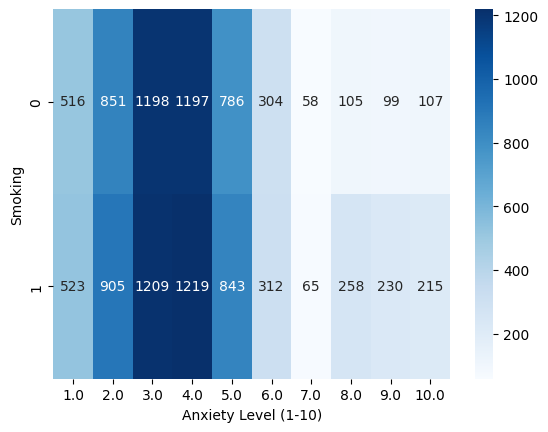

In [109]:
sns.heatmap(ct1, annot=True, cmap='Blues', fmt='d')

Тепловая карта наглядно визуализирует распределение респондентов по уровням тревожности в зависимости от курения. Интенсивность цвета отражает количество наблюдений: наиболее темные оттенки соответствуют средним уровням тревожности (3–5 баллов) в обеих группах. Визуально заметно, что среди курящих (True) с высокими уровнями тревожности (8–10 баллов) цвет ячеек более насыщенней по сравнению с некурящими (False).

In [110]:
stats.chi2_contingency(ct1)

Chi2ContingencyResult(statistic=np.float64(129.35444334035554), pvalue=np.float64(1.6098818188050873e-23), dof=9, expected_freq=array([[ 493.14718182,  833.46145455, 1142.44972727, 1146.72145455,
         773.18263636,  292.376     ,   58.38027273,  172.293     ,
         156.15536364,  152.83290909],
       [ 545.85281818,  922.53854545, 1264.55027273, 1269.27854545,
         855.81736364,  323.624     ,   64.61972727,  190.707     ,
         172.84463636,  169.16709091]]))

Все ячейки имеют частоту больше 5, следовательно тест Хи-квадрат применим.

In [111]:
print('chi2 = ', stats.chi2_contingency(ct1)[0], '   p-value =', stats.chi2_contingency(ct1)[1])

chi2 =  129.35444334035554    p-value = 1.6098818188050873e-23


H0: Нет связи между курением и уровнем тревожности.

H1: Существует связь между курением и уровнем тревожности.

p-value = 1.61e-23 < 0.05 (стандартный уровень значимости — 5%)

p-value = 1.61e-23 < 0.01

Гипотеза H1 принимается на уровне значимости 1%. Это означает, что между курением и уровнем тревожности существует статистически значимая взаимосвязь (гипотеза 3 подтвердилась).

### Гипотеза 5

Признаки: Anxiety Level (1-10), Family History of Anxiety

In [112]:
pd.pivot_table(df, values='Anxiety Level (1-10)', index='Family History of Anxiety', aggfunc={'Anxiety Level (1-10)': ['mean', 'median', 'std', 'min', 'max', 'count']})

,count,max,mean,median,min,std
Family History of Anxiety,,,,,,
0,5153,10.0,3.497768,3.0,1.0,1.814699
1,5847,10.0,4.309731,4.0,1.0,2.294592


Сводная таблица демонстрирует различия в уровне тревожности между людьми с наличием и отсутствием семейной истории тревожности. У респондентов, имеющих семейную историю (True), средний уровень тревожности выше (4.31), чем у тех, у кого она отсутствует (3.50). Медиана также различается: в группе с семейной историей она составляет 4 балла, в группе без нее — 3 балла. При этом максимальные значения (10) и минимальные (1) совпадают в обеих группах. Стандартное отклонение в группе с семейной историей (2.29) выше, что указывает на большую вариативность уровня тревожности среди этих респондентов. Полученные результаты согласуются с гипотезой о том, что наличие семейной истории тревожности связано с более высоким уровнем тревожности.

In [113]:
ct2 = pd.crosstab(df['Family History of Anxiety'], df['Anxiety Level (1-10)'])
ct2

Anxiety Level (1-10),1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
Family History of Anxiety,,,,,,,,,,
0,631,956,1189,1167,691,267,41,69,70,72
1,408,800,1218,1249,938,349,82,294,259,250


Таблица сопряженности показывает, что респонденты с семейной историей тревожности значительно чаще имеют высокие уровни тревожности (8–10 баллов) — 803 человека против 211 среди тех, у кого семейная история отсутствует, что подтверждает связь между этими факторами.

<Axes: xlabel='Anxiety Level (1-10)', ylabel='Family History of Anxiety'>

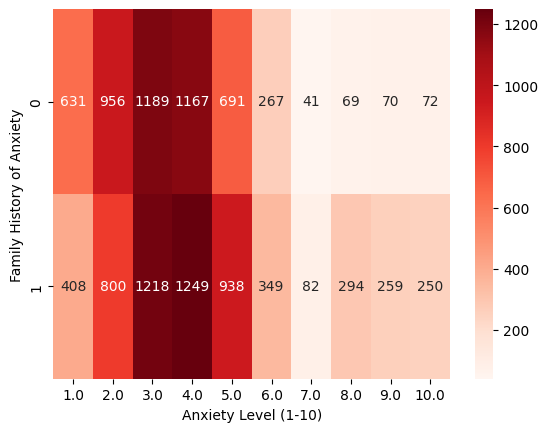

In [114]:
sns.heatmap(ct2, annot=True, cmap='Reds', fmt='d')

Наиболее темные оттенки красного соответствуют наибольшему количеству наблюдений и приходятся на средние уровни тревожности (3–5 баллов) в обеих группах. При этом в группе с семейной историей (True) наблюдается более интенсивная окраска в правой части тепловой карты (уровни 8–10), что указывает на существенно большее количество людей с высокой тревожностью по сравнению с группой без семейной истории.

In [115]:
stats.chi2_contingency(ct2)

Chi2ContingencyResult(statistic=np.float64(431.254002916778), pvalue=np.float64(2.9092001276945607e-87), dof=9, expected_freq=array([[ 486.72427273,  822.60618182, 1127.57009091, 1131.78618182,
         763.11245455,  288.568     ,   57.61990909,  170.049     ,
         154.12154545,  150.84236364],
       [ 552.27572727,  933.39381818, 1279.42990909, 1284.21381818,
         865.88754545,  327.432     ,   65.38009091,  192.951     ,
         174.87845455,  171.15763636]]))

Все ячейки имеют частоту больше 5, следовательно тест Хи-квадрат применим.

In [116]:
print('chi2 = ', stats.chi2_contingency(ct2)[0], '   p-value =', stats.chi2_contingency(ct2)[1])

chi2 =  431.254002916778    p-value = 2.9092001276945607e-87


H0: Нет связи между семейной историей тревожности и уровнем тревожности.  

H1: Существует связь между семейной историей тревожности и уровнем тревожности.

p-value = 2.91e-87 < 0.05 (стандартный уровень значимости — 5%)

p-value = 2.91e-87 < 0.01

Гипотеза H1 принимается на уровне значимости 1%. Это означает, что между семейной историей тревожности и уровнем тревожности существует статистически значимая взаимосвязь.

### Гипотеза 7

Признаки: Anxiety Level (1-10), Recent Major Life Event

In [117]:
pd.pivot_table(df, values='Anxiety Level (1-10)', index='Recent Major Life Event', aggfunc={'Anxiety Level (1-10)': ['mean', 'median', 'std', 'min', 'max', 'count']})

,count,max,mean,median,min,std
Recent Major Life Event,,,,,,
0,5377,10.0,3.759531,4.0,1.0,1.929374
1,5623,10.0,4.091766,4.0,1.0,2.280439


Сводная таблица показывает различия в уровне тревожности между людьми, пережившими и не пережившими недавние важные жизненные события. У респондентов, столкнувшихся с такими событиями (True), средний уровень тревожности выше (4.09), чем у тех, у кого событий не было (3.76). Медиана в обеих группах совпадает и составляет 4 балла. Максимальные (10) и минимальные (1) значения также одинаковы в обеих группах. При этом стандартное отклонение в группе с недавними событиями (2.28) выше, что указывает на большую вариативность уровня тревожности среди этих респондентов. Полученные результаты согласуются с гипотезой о том, что недавние важные события в жизни могут быть связаны с более высоким уровнем тревожности.

In [118]:
ct3 = pd.crosstab(df['Recent Major Life Event'], df['Anxiety Level (1-10)'])
ct3

Anxiety Level (1-10),1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
Recent Major Life Event,,,,,,,,,,
0,529,870,1224,1224,828,311,65,119,105,102
1,510,886,1183,1192,801,305,58,244,224,220


Таблица сопряженности иллюстрирует распределение уровней тревожности среди респондентов, переживших и не переживших недавние важные события. На низких и средних уровнях тревожности (1–6 баллов) группы демонстрируют схожие показатели с небольшим преобладанием то одной, то другой группы. Однако на высоких уровнях тревожности (8–10 баллов) различия становятся существенными: среди респондентов, переживших недавние события, насчитывается 688 человек с высокой тревожностью, тогда как среди не переживших — только 326 (в 2 раза меньше).

<Axes: xlabel='Anxiety Level (1-10)', ylabel='Recent Major Life Event'>

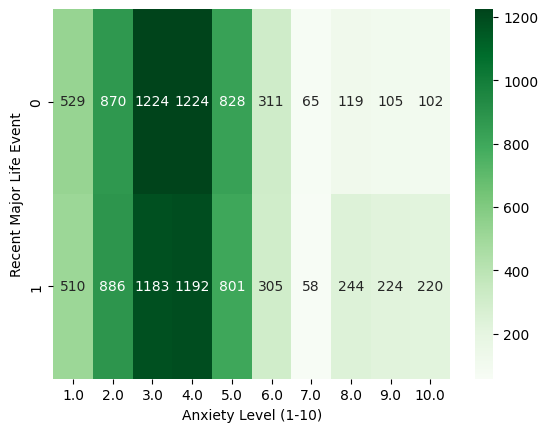

In [119]:
sns.heatmap(ct3, annot=True, cmap='Greens', fmt='d')

Тепловая карта наглядно визуализирует таблицу сопряженности между наличием недавних важных событий и уровнем тревожности. Наиболее темные оттенки приходятся на средние уровни тревожности (3–5 баллов) в обеих группах. При этом в группе, переживших недавние события (True), наблюдается более интенсивная окраска в правой части тепловой карты (уровни 8–10), что указывает на значительно большее количество людей с высокой тревожностью по сравнению с группой без событий.

In [120]:
stats.chi2_contingency(ct3)

Chi2ContingencyResult(statistic=np.float64(126.41041921827878), pvalue=np.float64(6.481056836465602e-23), dof=9, expected_freq=array([[ 507.88209091,  858.36472727, 1176.58536364, 1180.98472727,
         796.28481818,  301.112     ,   60.12463636,  177.441     ,
         160.82118182,  157.39945455],
       [ 531.11790909,  897.63527273, 1230.41463636, 1235.01527273,
         832.71518182,  314.888     ,   62.87536364,  185.559     ,
         168.17881818,  164.60054545]]))

Все ячейки имеют частоту больше 5, следовательно тест Хи-квадрат применим.

In [121]:
print('chi2 = ', stats.chi2_contingency(ct3)[0], '   p-value =', stats.chi2_contingency(ct3)[1])

chi2 =  126.41041921827878    p-value = 6.481056836465602e-23


H0: Нет связи между наличием недавних важных событий в жизни и уровнем тревожности.

H1: Существует связь между наличием недавних важных событий в жизни и уровнем тревожности.

p-value = 6.48e-23 < 0.05 (стандартный уровень значимости — 5%)

p-value = 6.48e-23 < 0.01

Гипотеза H1 принимается на уровне значимости 1%. Это означает, что между наличием недавних важных событий в жизни и уровнем тревожности существует статистически значимая взаимосвязь.

## Модель бинарной регрессии

Для проверки гипотез о влиянии бинарных факторов на вероятность высокого уровня тревожности построим модель бинарной логистической регрессии.

Все независимые переменные (Family History of Anxiety, Recent Major Life Event, Dizziness, Medication, Smoking) являются бинарными, что делает логистическую регрессию наиболее подходящим инструментом для анализа их влияния на тревожность.

Но для начала создадим столбец 'High Anxiety', который имеет занчения 'True' (если 'Anxiety Level (1-10)' >= 8), 'False' (иначе).

In [122]:
df['High Anxiety'] = (df['Anxiety Level (1-10)'] >= 8).astype(int)
print(df['High Anxiety'].value_counts())

High Anxiety
0    9986
1    1014
Name: count, dtype: int64


In [123]:
df_model2 = df.dropna(subset=['High Anxiety', 'Smoking', 'Family History of Anxiety',
                              'Recent Major Life Event', 'Dizziness',
                              'Medication'])
df_model2.shape

(11000, 21)

In [124]:
x_mult = df_model2[['Smoking', 'Family History of Anxiety',
                    'Recent Major Life Event', 'Dizziness',
                    'Medication']]
y = df_model2['High Anxiety']
x_mult_constant = sm.add_constant(x_mult)

In [125]:
model2 = sm.Logit(y, x_mult_constant).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.271709
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           High Anxiety   No. Observations:                11000
Model:                          Logit   Df Residuals:                    10994
Method:                           MLE   Df Model:                            5
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                  0.1166
Time:                        20:14:59   Log-Likelihood:                -2988.8
converged:                       True   LL-Null:                       -3383.1
Covariance Type:            nonrobust   LLR p-value:                3.294e-168
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -4.9203      0.123    -40.044      0.000      -5.

In [126]:
print('R^2 = {:f}'.format(model2.prsquared))
print('Model significance = {:f}'.format(model2.llr_pvalue))

R^2 = 0.116557
Model significance = 0.000000


Модель статистически значима и объясняет 11.7% изменчивости значений зависимой переменной.

In [127]:
f'Статистически значимые предикторы: {model2.pvalues[model2.pvalues < 0.05].index.values}'

"Статистически значимые предикторы: ['const' 'Smoking' 'Family History of Anxiety' 'Recent Major Life Event'\n 'Dizziness' 'Medication']"

In [128]:
f'Статистически не значимые предикторы: {model2.pvalues[model2.pvalues > 0.05].index.values}'

'Статистически не значимые предикторы: []'

In [129]:
l = []
for (param, index) in zip(model2.params[1:], model2.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('logit(p) = {:2f} + {}'.format(model2.params[0], ' + '.join(l)))

logit(p) = -4.920334 + 0.81*Smoking + 1.36*Family History of Anxiety + 0.79*Recent Major Life Event + 0.93*Dizziness + 0.40*Medication


/tmp/ipykernel_10006/3768618427.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('logit(p) = {:2f} + {}'.format(model2.params[0], ' + '.join(l)))


Детальная интерпритация модели:

Наличие привычки курения увеличивает шансы попадания в группу с высоким уровнем тревожности. Коэффициент (0.81) положителен и статистически значим (p < 0.05).

Наличие семейной истории тревожности увеличивает шансы высокого уровня тревожности. Это фактор с наибольшим коэффициентом (1.36), что делает его самым сильным предиктором среди всех включенных переменных.

Наличие недавних жизненных событий увеличивает шансы высокой тревожности (коэффициент 0.79, p < 0.05).

Наличие эпизодов головокружения увеличивает шансы высокого уровня тревожности (коэффициент 0.93, p < 0.05).

Прием лекарственных препаратов также увеличивает шансы высокой тревожности, однако этот фактор имеет наименьшее влияние среди всех предикторов (коэффициент 0.40, p < 0.05).

Таким образом, результаты бинарной логистической регрессии согласуются с выводами, полученными на основе сводных таблиц и критерия Хи-квадрат, и подтверждают, что ключевыми факторами, связанными с повышенной вероятностью высокого уровня тревожности, являются наличие семейной истории тревожности, курение, недавние жизненные события и головокружение, тогда как прием лекарств играет менее значимую роль.

## Описательные статистики

Для проверки гипотез 2 и 11 был выбран методом описательной статистика, так как эти гипотезы направлены на сравнение уровня тревожности между независимыми группами (по признакам пола и возраста). Описательные статистики (среднее, медиана, стандартное отклонение) позволяют количественно оценить различия в центральной тенденции и вариативности значений между группами, а визуализация с помощью boxplot дает наглядное представление о распределении данных.

### Гипотеза 2

Признаки: Gender, Anxiety Level (1-10)

In [130]:
df.groupby('Gender')['Anxiety Level (1-10)'].describe()

/tmp/ipykernel_10006/4215826570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Anxiety Level (1-10)'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,3730.0,3.931367,2.126240,1.0,2.0,4.0,5.0,10.0
Male,3657.0,3.933552,2.145861,1.0,2.0,4.0,5.0,10.0
Other,3613.0,3.923056,2.095360,1.0,3.0,4.0,5.0,10.0


Анализ описательных статистик показывает, что средний уровень тревожности во всех трех группах практически идентичен и составляет около 3.92–3.93 балла. Медиана во всех группах также совпадает и равна 4.0 балла.

Минимальные (1.0) и максимальные (10.0) значения одинаковы для всех групп. Небольшие различия наблюдаются в первой группе (25%): у женщин и мужчин он составляет 2.0 балла, тогда как в группе 'Other' — 3.0 балла, что указывает на несколько более высокий нижний порог тревожности в данной группе.

Стандартные отклонения во всех группах близки по значению (около 2.1), что свидетельствует о схожей вариативности уровня тревожности независимо от пола.

Таким образом, вопреки гипотезе 2, значимых различий в уровне тревожности между женщинами, мужчинами и другим полом не обнаружено.

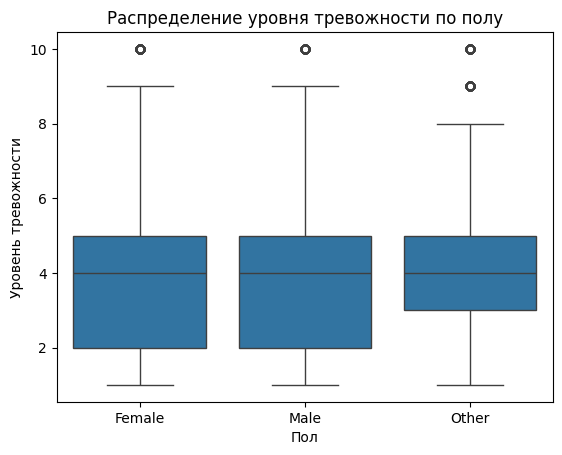

In [131]:
sns.boxplot(x='Gender', y='Anxiety Level (1-10)', data=df)
plt.title('Распределение уровня тревожности по полу')
plt.xlabel('Пол')
plt.ylabel('Уровень тревожности')
plt.show()

Диаграмма наглядно демонстрирует распределение уровня тревожности среди людей разного пола. Во всех трех группах медиана составляет 4 балла, что совпадает с результатами описательной статистики. Межквартильный размах (ящик) также схож во всех группах, указывая на аналогичное распределение средних 50% наблюдений. В группах Female и Male наблюдаются выбросы в области высоких значений (8–10 баллов), что свидетельствует о наличии респондентов с крайне высокой тревожностью независимо от пола. Визуальный анализ подтверждает вывод об отсутствии существенных различий в уровне тревожности между группами.

### Гипотеза 11

Признаки: Age, Anxiety Level (1-10)

In [132]:
df.groupby('Age')['Anxiety Level (1-10)'].describe()

,count,mean,std,min,25%,50%,75%,max
Age,,,,,,,,
Adults,3245.0,3.754391,1.850721,1.0,3.0,4.0,5.0,10.0
Elderly people,1051.0,3.491912,1.437816,1.0,2.0,3.0,5.0,8.0
Young people,6704.0,4.082637,2.311431,1.0,2.0,4.0,5.0,10.0


Анализ описательных статистик выявляет различия в уровне тревожности между возрастными группами. Наиболее высокий средний уровень тревожности наблюдается у молодых людей (Young people) — 4.08 балла, тогда как у взрослых (Adults) он составляет 3.75 балла, а у пожилых (Elderly people) — 3.49 балла.

Медиана также различается: у молодых и взрослых она равна 4.0 балла, у пожилых — 3.0 балла. Минимальные значения во всех группах одинаковы (1.0), однако максимальные различаются: у пожилых максимальный уровень тревожности составляет 8.0 баллов, тогда как в остальных группах встречаются значения до 10.0 баллов.

Стандартное отклонение наиболее высокое в группе молодых (2.31), что указывает на большую вариативность уровня тревожности среди этой возрастной категории.

Полученные результаты подтверждают гипотезу 11 о том, что молодые люди имеют более высокий уровень тревожности по сравнению с другими возрастными группами.

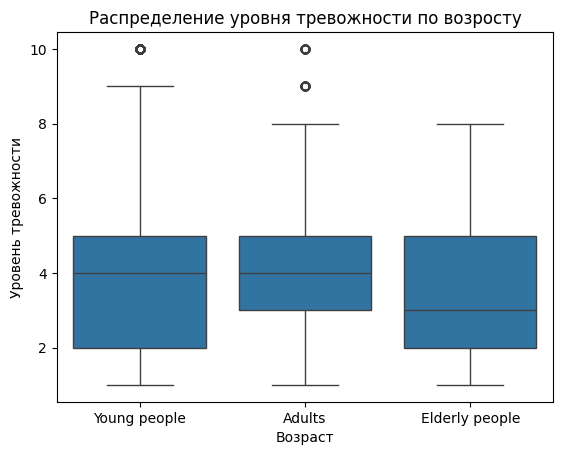

In [133]:
sns.boxplot(x='Age', y='Anxiety Level (1-10)', data=df)
plt.title('Распределение уровня тревожности по возросту')
plt.xlabel('Возраст')
plt.ylabel('Уровень тревожности')
plt.show()

График показывает различия в распределении уровня тревожности между возрастными группами. У молодых людей (Young people) медиана составляет 4 балла, при этом наблюдается наибольший разброс значений и множество выбросов в области высоких показателей (8–10 баллов). У взрослых (Adults) медиана также равна 4 баллам, но межквартильный размах несколько уже, а выбросов меньше. В группе пожилых людей (Elderly people) медиана составляет 3 балла, разброс значений наименьший, а максимальные значения не превышают 8 баллов. Визуальный анализ подтверждает выводы описательной статистики: уровень тревожности наиболее высок и вариативен среди молодых людей и снижается в старших возрастных группах.

## Кластерный анализ

Для проверки гипотезы 10 был выбран метод кластерного анализа. Данный выбор обусловлен следующей причиной: данная гипотеза направлена на выявление естественных группировок объектов на основе комплекса признаков (продолжительность сна, физическая активность, потребление кофеина и уровень тревожности).

In [134]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score

### Гипотеза 10

Признаки: Sleep Hours, Physical Activity (hrs/week), Caffeine Intake (mg/day), Diet Quality (1-10), Alcohol Consumption (drinks/week), Anxiety Level (1-10), Lifestyle Score

In [135]:
# Стандартизируем значения переменных
df['z_Sleep Hours'] = (df['Sleep Hours'] - df['Sleep Hours'].mean())/df['Sleep Hours'].std()
df['z_Physical Activity (hrs/week)'] = (df['Physical Activity (hrs/week)'] - df['Physical Activity (hrs/week)'].mean())/df['Physical Activity (hrs/week)'].std()
df['z_Caffeine Intake (mg/day)'] = (df['Caffeine Intake (mg/day)'] - df['Caffeine Intake (mg/day)'].mean())/df['Caffeine Intake (mg/day)'].std()
df['z_Diet Quality (1-10)'] = (df['Diet Quality (1-10)'] - df['Diet Quality (1-10)'].mean())/df['Diet Quality (1-10)'].std()
df['z_Alcohol Consumption (drinks/week)'] = (df['Alcohol Consumption (drinks/week)'] - df['Alcohol Consumption (drinks/week)'].mean())/df['Alcohol Consumption (drinks/week)'].std()
df['z_Anxiety Level (1-10)'] = (df['Anxiety Level (1-10)'] - df['Anxiety Level (1-10)'].mean())/df['Anxiety Level (1-10)'].std()

variables = [
    'z_Sleep Hours',
    'z_Physical Activity (hrs/week)',
    'z_Caffeine Intake (mg/day)',
    'z_Diet Quality (1-10)',
    'z_Alcohol Consumption (drinks/week)',
    'z_Anxiety Level (1-10)'
]

# Строим таблицу корреляции
df[variables].corr()

,z_Sleep Hours,z_Physical Activity (hrs/week),z_Caffeine Intake (mg/day),z_Diet Quality (1-10),z_Alcohol Consumption (drinks/week),z_Anxiety Level (1-10)
z_Sleep Hours,1.000000,0.174526,-0.208659,0.154110,-0.068068,-0.493836
z_Physical Activity (hrs/week),0.174526,1.000000,-0.115298,0.085587,-0.032936,-0.243187
z_Caffeine Intake (mg/day),-0.208659,-0.115298,1.000000,-0.089457,0.036401,0.350651
z_Diet Quality (1-10),0.154110,0.085587,-0.089457,1.000000,-0.029601,-0.220245
z_Alcohol Consumption (drinks/week),-0.068068,-0.032936,0.036401,-0.029601,1.000000,0.100626
z_Anxiety Level (1-10),-0.493836,-0.243187,0.350651,-0.220245,0.100626,1.000000


По вашей таблице видно, что корреляция между переменными не превышает 0.49 (связь между z_Sleep Hours и z_Anxiety Level), что свидетельствует об отсутствии сильной мультиколлинеарности. Данные переменные подходят для кластерного анализа.

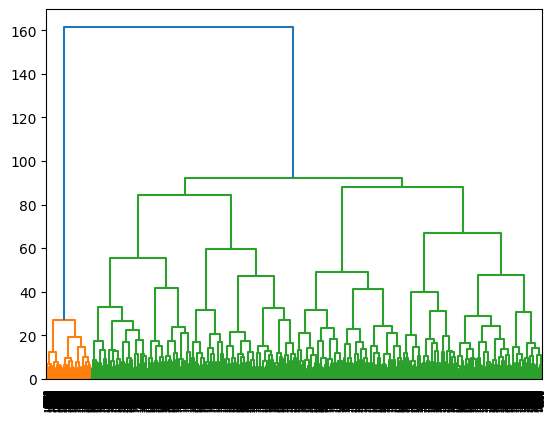

In [136]:
df1 = df[variables].dropna()
dn = dendrogram(linkage(df1, 'ward'))

На основе визуального анализа дендрограммы выдвинута гипотеза о наличии двух кластеров. Для проверки гипотезы рассчитаем индекс Калински-Харабаза.

In [137]:
Z = linkage(df1, method='ward', metric='euclidean')
for k in range (2, 10):
    labels = fcluster(Z, t=k, criterion='maxclust')
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(df1, labels)))

Число кластеров: 2, индекс 2713.1243409583994
Число кластеров: 3, индекс 1954.4168548650723
Число кластеров: 4, индекс 1732.5070477194572
Число кластеров: 5, индекс 1649.7931438866635
Число кластеров: 6, индекс 1521.6798390883407
Число кластеров: 7, индекс 1416.0354853942208
Число кластеров: 8, индекс 1334.413495194496
Число кластеров: 9, индекс 1256.4839558540305


Максимальное значение индекса достигается при двух кластерах.

In [138]:
labels = fcluster(Z, t=2, criterion='maxclust')
df1['culster_labels'] = labels
df1.groupby('culster_labels').mean(numeric_only=True).T

culster_labels,1,2
z_Sleep Hours,-1.707400,0.172996
z_Physical Activity (hrs/week),-0.983340,0.099634
z_Caffeine Intake (mg/day),1.125260,-0.114013
z_Diet Quality (1-10),-0.912974,0.092504
z_Alcohol Consumption (drinks/week),0.369043,-0.037392
z_Anxiety Level (1-10),2.366143,-0.239741


Кластер 1: «Тревожные с нездоровым образом жизни»

Обоснование названия: В данном кластере наблюдаются резко повышенный уровень тревожности (+2.37 стандартных отклонения) в сочетании с крайне низкими показателями качества сна, физической активности и питания, а также повышенным потреблением кофеина и алкоголя.

Характеристики:

- Максимально высокий уровень тревожности (+2.37) — самый сильный показатель
- Крайне низкая продолжительность сна (-1.71)
- Очень низкая физическая активность (-0.98)
- Повышенное потребление кофеина (+1.13)
- Низкое качество питания (-0.91)
- Повышенное потребление алкоголя (+0.37)

Кластер 2: «Спокойные со здоровым образом жизни»

Обоснование названия: Кластер характеризуется показателями образа жизни выше среднего и уровнем тревожности ниже среднего, что указывает на благоприятное сочетание факторов.

Характеристики:

- Уровень тревожности ниже среднего (-0.24)
- Хорошая продолжительность сна (+0.17)
- Физическая активность выше среднего (+0.10)
- Пониженное потребление кофеина (-0.11)
- Качество питания выше среднего (+0.09)
- Умеренное потребление алкоголя (-0.04)

Проверим как распределены занчения признака 'Lifestyle Score' по кластерам.

In [139]:
# Сохраняем индексы строк, которые остались после удаления пропусков
clean_idx = df1.index

# Создаем столбец с кластерами, заполняем NaN
df['Cluster'] = np.nan

# Заполняем кластерные метки только для строк, которые были в кластеризации
df.loc[clean_idx, 'Cluster'] = labels

In [140]:
df.groupby(['Lifestyle Score', 'Cluster']).size().unstack(fill_value=0)

Cluster,1.0,2.0
Lifestyle Score,,
Healthy,2,3987
Unhealthy,1010,6001


В кластере 2 преобладают респонденты с нездоровым образом жизни (60%), однако их показатели образа жизни ближе к средним, а уровень тревожности ниже. Это может указывать на то, что нездоровый образ жизни не всегда сопровождается высокой тревожностью при отсутствии других факторов.

В результате кластерного анализа было выделено два кластера:

- Кластер 1 («Тревожные с нездоровым образом жизни») объединил респондентов с крайне высоким уровнем тревожности (+2.37 стандартных отклонения), низкой продолжительностью сна, низкой физической активностью, низким качеством питания, а также повышенным потреблением кофеина и алкоголя. Практически все представители данного кластера (99.8%) имеют нездоровый образ жизни.
- Кластер 2 («Спокойные со сбалансированным образом жизни») включает респондентов с уровнем тревожности ниже среднего и показателями образа жизни, близкими к средним значениям или незначительно превышающими их.

Гипотеза 10 подтверждается частично. Действительно, существует кластер (Кластер 1), в котором нездоровый образ жизни сочетается с высокой тревожностью. Однако во втором кластере также присутствует значительная доля респондентов с нездоровым образом жизни (60%), но при этом уровень тревожности у них ниже среднего. Это позволяет предположить, что нездоровый образ жизни может быть фактором риска, но не является единственным показателем высокого уровня тревожности и проявляется в сочетании с другими особенностями.


## Подведение итогов

Выводы по исследовательским гипотезам

| Гипотеза | Суть гипотезы | Результат | Обоснование |
|----------|---------------|-----------|-------------|
| **Гипотеза 1** | Связь между сном и тревожностью | **Подтверждена** | Обнаружена умеренная отрицательная корреляция (r = -0.49, p < 0.05). Регрессионный анализ подтвердил: +1 час сна снижает тревожность на 0.55 балла. |
| **Гипотеза 2** | Женщины тревожнее мужчин | **Отвергнута** | Средние значения практически идентичны (3.93 у женщин, 3.93 у мужчин). Медиана (4) и разброс значений схожи во всех группах. |
| **Гипотеза 3** | Физическая активность снижает тревожность | **Подтверждена** | Слабая отрицательная корреляция (r = -0.18, p < 0.05). Каждый доп. час активности снижает тревожность на 0.11 балла. |
| **Гипотеза 4** | Курение связано с более высокой тревожностью | **Подтверждена** | Средний уровень тревожности у курящих выше (4.09 против 3.75). Хи-квадрат: p < 0.05. В бинарной регрессии коэффициент 0.81 (p < 0.05). |
| **Гипотеза 5** | Семейная история повышает риск тревожности | **Подтверждена** | Средние значения: 4.31 (с историей) против 3.50 (без). Хи-квадрат: p < 0.05. Самый сильный предиктор в бинарной регрессии (коэф. 1.36). |
| **Гипотеза 6** | Связь стресса и частоты сердцебиения | **Подтверждена** | Очень слабая положительная связь (r = 0.09). Направление соответствует гипотезе, но влияние минимально. |
| **Гипотеза 7** | Недавние события повышают тревожность | **Подтверждена** | Средние значения: 4.09 (с событиями) против 3.76 (без). Хи-квадрат: p < 0.05. Бинарная регрессия: коэф. 0.79. |
| **Гипотеза 8** | Качество питания связано с тревожностью | **Подтверждена** | Слабая отрицательная корреляция Спирмена (ρ = -0.15, p < 0.05). Регрессия: +1 балл качества питания снижает тревожность на 0.06 балла. |
| **Гипотеза 9** | Кофеин повышает физиологические показатели | **Подтверждена** | Крайне слабые корреляции: с дыханием (r = 0.08), пульсом (r = 0.08), потливостью (r = 0.07), p < 0.05. |
| **Гипотеза 10** | Нездоровый образ жизни связан с высокой тревожностью | **Подтверждена** | Выделен кластер с нездоровым образом жизни и экстремально высокой тревожностью. Однако во втором кластере 60% с нездоровым образом жизни имеют тревожность ниже среднего. |
| **Гипотеза 11** | Молодые люди тревожнее старших возрастных групп | **Подтверждена** | Средние значения: молодые (4.08), взрослые (3.75), пожилые (3.49). Медиана у пожилых (3) ниже, чем в других группах (4). |

Достижение цели и задач исследования

Целью данного исследования являлся комплексный анализ факторов, влияющих на уровень социальной тревожности. В ходе работы были решены все поставленные задачи:

1. Сформулированы и проверены 11 исследовательских гипотез с использованием соответствующих статистических методов.
2. Проведен корреляционный анализ, выявивший ключевые связи между изучаемыми признаками.
3. Построены модели линейной и бинарной регрессии, позволившие количественно оценить влияние факторов.
4. Выполнен кластерный анализ, выделивший группы респондентов со схожими паттернами образа жизни и тревожности.
5. Проведена визуализация данных с помощью графиков и тепловых карт, наглядно демонстрирующих выявленные закономерности.

Таким образом, цель исследования полностью достигнута, все задачи реализованы.

Общие выводы

Ключевые факторы тревожности. Наиболее сильное влияние на уровень тревожности оказывают уровень стресса и продолжительность сна. Эти факторы являются основными предикторами как в корреляционном, так и в регрессионном анализе.

Роль поведенческих факторов. Физическая активность и качество питания демонстрируют слабое отрицательное влияние на тревожность, тогда как потребление кофеина и алкоголя — крайне слабое положительное. Поведенческие факторы играют менее значимую роль по сравнению со стрессом и сном.

Бинарные факторы риска. Курение, наличие семейной истории тревожности и недавние жизненные события статистически значимо повышают вероятность высокого уровня тревожности. Наиболее сильным предиктором среди них является семейная история.

Демографические различия. Вопреки ожиданиям, значимых различий в уровне тревожности между мужчинами и женщинами не обнаружено. Возрастные различия подтвердились: молодые люди демонстрируют наиболее высокий уровень тревожности.

Кластерная структура. Выделено два кластера: «Тревожные с нездоровым образом жизни» (экстремально высокая тревожность, низкие показатели сна, активности, питания) и «Спокойные со сбалансированным образом жизни» (тревожность ниже среднего, показатели образа жизни близки к средним).

Ожидаемые и неожиданные выводы

Ожидаемые выводы:

- Сильная связь между стрессом и тревожностью.
- Снижение тревожности при увеличении продолжительности сна.
- Более высокий уровень тревожности у курящих и у людей с семейной историей тревожности.
- Наиболее высокий уровень тревожности среди молодых людей.

Неожиданные выводы:

- Отсутствие различий между мужчинами и женщинами. Предполагалось, что женщины будут демонстрировать более высокий уровень тревожности, однако статистика этого не подтвердила.
- Крайне слабое влияние кофеина на физиологические показатели (пульс, дыхание, потливость). Ожидалась более выраженная связь.
- Наличие во втором кластере большого количества респондентов с нездоровым образом жизни, но низкой тревожностью. Это указывает на то, что нездоровый образ жизни сам по себе не является достаточным условием для развития высокой тревожности и требует сочетания с другими факторами.

# ЧАСТЬ №2

---


Задача второй части заключается в сборе данных о преподавателях ФКН НИУ ВШЭ. Для каждого преподавателя необходимо найти и зафиксировать следующую информацию: ФИО, должность, год начала работы в НИУ ВШЭ, стаж, изучаемые языки, телефон, адрес кабинета, расписание, научные интересы, полномочия и обязанности, достижения, образование. В случае отсутствия каких-либо данных на сайте соответствующая ячейка остается пустой.


In [141]:
import requests
page = requests.get('https://cs.hse.ru/dse/persons/')

In [142]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(page.text, 'html.parser')

In [143]:
print(soup.prettify())

<!DOCTYPE html>
<html lang="ru">
 <head>
  <title>
   Сотрудники – Департамент программной инженерии – Национальный исследовательский университет «Высшая школа экономики»
  </title>
  <meta content="IE=Edge" http-equiv="X-UA-Compatible"/>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <meta content="#1658DA" name="theme-color"/>
  <link href="/f/src/global/css/main.css" rel="stylesheet"/>
  <link href="/f/src/global/css/fotorama.css" rel="stylesheet"/>
  <link href="/f/src/global/css/sitemap.css" rel="stylesheet"/>
  <link href="/f/src/home/owl.carousel.css" rel="stylesheet"/>
  <link href="/f/src/projects/faculty/faculty.css" rel="stylesheet"/>
  <link href="/f/src/global/css/magnific-popup.min.css" rel="stylesheet"/>
  <link href="/f/src/global/css/vision.css" rel="stylesheet">
   <meta content="summary" name="twitter:card"/>
   <meta content="Департамент программной инженерии" property=

In [144]:
soup.find_all('a')

[<a href="https://www.hse.ru/cookie.html" rel="nofollow noopener" target="_blank" title="Пройти по ссылке">здесь</a>,
 <a href="https://www.hse.ru/data_protection_regulation" rel="nofollow noopener" target="_blank" title="Пройти по ссылке">здесь</a>,
 <a class="control control_home_white" href="//www.hse.ru/"><ins><svg class="control_svg" fill="none" height="30" viewbox="0 0 309 309" width="30" xmlns="http://www.w3.org/2000/svg">
 <path class="control__path" clip-rule="evenodd" d="M68.4423 26.0393C93.7686 9.06174 123.545 0 154.005 0C194.846 0 234.015 16.275 262.896 45.2451C291.777 74.2153 308.005 113.508 308.01 154.481C308.013 185.039 298.984 214.911 282.065 240.321C265.145 265.731 241.094 285.537 212.953 297.234C184.813 308.931 153.847 311.993 123.972 306.034C94.0966 300.074 66.6537 285.361 45.1138 263.755C23.5739 242.148 8.90442 214.619 2.96053 184.649C-2.98335 154.678 0.0653089 123.612 11.721 95.3799C23.3767 67.1476 43.1159 43.0168 68.4423 26.0393ZM180.336 140.561C212.051 151.8 224.

In [145]:
for link in soup.find_all('a'):
    print(link.get('href'))

https://www.hse.ru/cookie.html
https://www.hse.ru/data_protection_regulation
//www.hse.ru/
https://cs.hse.ru/en/dse/persons/
https://cs.hse.ru/dse/?vision=enabled
//www.hse.ru/lkuser/
//www.hse.ru/search/search.html?simple=0
//www.hse.ru
http://www.hse.ru/education/
http://cs.hse.ru/

https://www.hse.ru
https://cs.hse.ru/dse/persons/
https://cs.hse.ru/en/dse/persons/
https://cs.hse.ru/dse/?vision=enabled
//www.hse.ru/user/
//www.hse.ru/search/search.html?simple=0
https://cs.hse.ru/dse/
https://cs.hse.ru/
https://cs.hse.ru/dse/
https://cs.hse.ru/dse/about
https://cs.hse.ru/dse/dse20/
https://cs.hse.ru/dse/persons
https://cs.hse.ru/dse/aspirants
https://cs.hse.ru/dse/scientific_activity
https://cs.hse.ru/dse/seminar_sse/
https://cs.hse.ru/dse/media
http://cs.hse.ru/dse/sp
https://cs.hse.ru/dse/1c/
https://cs.hse.ru/dse/cmt-lab/
https://pais.hse.ru/
https://cs.hse.ru/dse/piki
https://cs.hse.ru/dse/ismed
None
https://www.hse.ru/buildinghse/list#pokr-s
//www.hse.ru/org/persons/202722706
//w

In [146]:
urls = list(set([a['href'] for a in soup.find_all("a", href=True)
                 if '/staff/' in a['href'] or '/persons/' in a['href']]))
urls

['//www.hse.ru/org/persons/1125816158',
 '//www.hse.ru/org/persons/305115659',
 '//www.hse.ru/org/persons/1090820340',
 '//www.hse.ru/org/persons/224668106',
 'https://www.hse.ru/org/persons/?intst=65554685',
 'https://www.hse.ru/org/persons/?elib=55233769',
 '//www.hse.ru/staff/ademakov',
 '//www.hse.ru/org/persons/209608913',
 'https://www.hse.ru/org/persons/?intst=39193896',
 'https://www.hse.ru/org/persons/?intst=76454947',
 'https://www.hse.ru/org/persons/?intst=1132194370',
 'https://www.hse.ru/org/persons/?intst=76713384',
 'https://www.hse.ru/org/persons/?intst=1038858581',
 'https://www.hse.ru/org/persons/?intst=129532424',
 'https://www.hse.ru/org/persons/?intst=82654337',
 '//www.hse.ru/org/persons/401606331',
 '//www.hse.ru/staff/nm.suvorov',
 '//www.hse.ru/org/persons/305132190',
 '//www.hse.ru/staff/Boris.Klimov',
 'https://www.hse.ru/org/persons/?elib=55231839',
 'https://www.hse.ru/org/persons/?intst=96399093',
 'https://www.hse.ru/org/persons/?intst=46351445',
 '//www.

In [149]:
url = urls[1]
if url.startswith('//'):
    url = 'https:' + url
page0 = requests.get(url)
soup0 = BeautifulSoup(page0.text, 'html.parser')
soup0

<!DOCTYPE html>
<html lang="ru"><head><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1" name="viewport"/><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><meta content="IE=Edge" http-equiv="X-UA-Compatible"/><link href="/f/src/global/i/favicon/favicon_ios_180x180.png" rel="apple-touch-icon" sizes="180x180"/><link href="/f/src/global/i/favicon/favicon_32x32.png" rel="icon" sizes="32x32" type="image/png"/><link href="/f/src/global/i/favicon/favicon_16x16.png" rel="icon" sizes="16x16" type="image/png"/><link color="#0F2D69" href="/f/src/global/i/favicon/favicon.svg" rel="mask-icon"/><link href="/f/src/manifest/manifest_ru.json" rel="manifest"/><meta content="/f/src/global/i/favicon/browserconfig.xml" name="msapplication-config"/><link href="https://www.hse.ru/org/persons/305115659/" rel="canonical"/><link href="/f/src/global/css/main.css?v2" media="all" rel="stylesheet"/><link href="/f/src/global/css/vision.css" media="all" rel="stylesheet"/><li

In [150]:
import numpy as np
import re

def GetEmployee(url0):
    try:
        # Проверяем и исправляем URL
        if url0.startswith('//'):
            # Если начинается с //, добавляем https:
            full_url = 'https:' + url0
        elif url0.startswith('/'):
            # Если начинается с /, добавляем домен
            full_url = 'https://www.hse.ru' + url0
        elif url0.startswith('http'):
            # Если уже содержит http, оставляем как есть
            full_url = url0
        else:
            # В остальных случаях пробуем добавить https://
            full_url = 'https://' + url0

        page0 = requests.get(full_url, headers={'User-Agent': 'Mozilla/5.0'})
        soup0 = BeautifulSoup(page0.text, 'html.parser')
    except Exception as e:
        return (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan,
                np.nan, np.nan, np.nan, np.nan, url0)

    # ФИО
    try:
        fio = soup0.find('h1', class_='person-caption').text.strip()
    except:
        fio = np.nan

    # Должность
    try:
        position = soup0.find('span', class_='person-appointment-title').text.strip().replace(':', '').capitalize()
    except:
        position = np.nan

    # Год начала работы
    try:
        data_work_HSE = re.search(r'\d+', soup0.find_all('li', class_='i')[0].text.strip()).group()
    except:
        data_work_HSE = np.nan

    # Стаж
    try:
        experience = re.search(r'\d+', soup0.find_all('li', class_='i')[1].text.strip()).group()
    except:
        experience = np.nan

    # Языки
    try:
        lang_block = soup0.find('dl', class_='main-list-language-knowledge-level')
        if lang_block:
            languages = ', '.join([lang.text.strip() for lang in lang_block.find_all('dd')])
        else:
            languages = np.nan
    except:
        languages = np.nan

    # Телефое
    try:
        contacts_dl = soup0.find('dl', class_='main-list large')
        if contacts_dl:
            phone_dd = contacts_dl.find('dd')
            if phone_dd:
                phone_text = phone_dd.text.strip().replace('Телефон:', '').strip()
                phone = phone_text if phone_text else np.nan
            else:
                phone = np.nan
        else:
            phone = np.nan
    except:
        phone = np.nan

    # Адрес
    try:
        address_dd = None
        for dd in soup0.find_all('dd'):
            classes = dd.get('class', [])
            if classes and any('address' in c for c in classes):
                address_dd = dd
                break

        if address_dd:
            full_text = address_dd.text.strip()
            if 'Время' in full_text:
                address = full_text.split('Время')[0].replace('\n', ' ').strip()
            else:
                address = full_text.replace('\n', ' ').strip()
        else:
            address = np.nan
    except:
        address = np.nan

    # Расписание
    try:
        if address_dd and 'Время' in address_dd.text.strip():
            full_text = address_dd.text.strip()
            schedule = 'Время ' + full_text.split('Время')[1].replace('\n', ' ').strip()
        else:
            schedule = np.nan
    except:
        schedule = np.nan

    # Научные интересы
    try:
        interests_list = []
        for item in soup0.find_all('a', class_='tag tag_small'):
            text = item.text.strip()
            if text:
                interests_list.append(text)
        interests = '\n'.join(interests_list) if interests_list else np.nan
    except:
        interests = np.nan

    # Полномочия
    try:
        responsibilities_list = []
        resp_block = soup0.find('div', {'tab-node': 'responsibilities'})
        if resp_block:
            for item in resp_block.find_all('p', class_='text'):
                text = item.text.strip()
                if text:
                    responsibilities_list.append(text)
            if not responsibilities_list:
                for item in resp_block.find_all('li'):
                    text = item.text.strip()
                    if text:
                        responsibilities_list.append(text)

        responsibilities = '\n'.join(responsibilities_list) if responsibilities_list else np.nan
    except:
        responsibilities = np.nan

    # Достижения
    try:
        achievements_list = []
        awards_block = soup0.find('div', {'tab-node': 'awards'})
        if awards_block:
            for item in awards_block.find_all('li'):
                text = item.text.strip()
                if text:
                    achievements_list.append(text)

        achievements = '\n'.join(achievements_list) if achievements_list else np.nan
    except:
        achievements = np.nan

    # Образование
    try:
        education_list = []
        edu_block = soup0.find('div', {'tab-node': 'sci-degrees1'})
        if edu_block:
            for item in edu_block.find_all('div', class_='g-ul'):
                text = item.text.strip()
                if text:
                    if text[:4].isdigit():
                        text = text[:4] + ' ' + text[4:]
                    education_list.append(text)

        education = '\n'.join(education_list) if education_list else np.nan
    except:
        education = np.nan

    return (fio, position, data_work_HSE, experience, languages, phone,
            address, schedule, interests, responsibilities, achievements, education, full_url)

In [151]:
from time import sleep

staff = []

# На сайте некоторых сотрудников нет никакой информации
# Поэтому если все извлекаемы столбцы = Nan, то мы пропускаем данного сотрудника
for link in urls[0:10]: # Для примера берем [0:10]
    res = GetEmployee(link)
    nan_count = sum(pd.isna(x) for x in res)
    if nan_count == 12:
      continue
    staff.append(res)
    sleep(1)
print(staff)

[('Лютенков Артем Вадимович', 'Приглашенный преподаватель', '2026', nan, '', '28240', 'Адрес: Покровский б-р', nan, 'Программирование на С++', nan, nan, '2021 Магистратура: Ярославский государственный университет им. П.Г. Демидова, специальность «Прикладная математика и информатика», квалификация «Магистр»', 'https://www.hse.ru/org/persons/1125816158'), ('Резуник Людмила', 'Преподаватель', '2023', nan, 'английский, румынский', '+7 (916) 932-91-77', 'Адрес: АУК "Покровский бульвар", Покровский б-р, д. 11, каб. S915', nan, 'мобильная разработка\nWeb-разработка\nоблачные сервисы\nразработка игр', '- участие в проектах Лаборатории облачных и мобильных технологий', 'Надбавка\xa0для молодых преподавателей ФКН из числа выпускников\xa0(2023-2024)\nБлагодарность факультета компьютерных наук НИУ ВШЭ (июль 2025)\nБлагодарность департамента программной инженерии НИУ ВШЭ (декабрь 2024)\nГруппа высокого профессионального потенциала (кадровый резерв НИУ ВШЭ)Категория "Новые преподаватели" (2024–2025)

In [152]:
columns = ['ФИО', 'Должность', 'Год начала работы', 'Стаж', 'Языки',
           'Телефон', 'Адрес', 'Расписание', 'Научные интересы',
           'Полномочия/Обязанности', 'Достижения', 'Образование', 'URL']

df = pd.DataFrame(staff, columns=columns)
df

,ФИО,Должность,Год начала работы,Стаж,Языки,Телефон,Адрес,Расписание,Научные интересы,Полномочия/Обязанности,Достижения,Образование,URL
0,Лютенков Артем Вадимович,Приглашенный преподаватель,2026,NaN,,28240,Адрес: Покровский б-р,NaN,Программирование на С++,NaN,NaN,2021 Магистратура: Ярославский государственный...,https://www.hse.ru/org/persons/1125816158
1,Резуник Людмила,Преподаватель,2023,NaN,"английский, румынский",+7 (916) 932-91-77,"Адрес: АУК ""Покровский бульвар"", Покровский б-...",NaN,мобильная разработка\nWeb-разработка\nоблачные...,- участие в проектах Лаборатории облачных и мо...,Надбавка для молодых преподавателей ФКН из чис...,2025 Магистратура: Национальный исследовательс...,https://www.hse.ru/org/persons/305115659
2,Куклина Ксения Михайловна,Приглашенный преподаватель,2026,NaN,,28240,"Адрес: Покровский Б-р, д.11",NaN,UX-дизайн,NaN,NaN,NaN,https://www.hse.ru/org/persons/1090820340
3,Силаев Юрий Владимирович,Преподаватель,2018,17,английский,28240,"Адрес: АУК ""Покровский бульвар"", Покровский б-...",Время работы: Пн-Пт 09.30-18.00,интеллектуальные системы\nнейросетевые техноло...,NaN,NaN,2007 Специалитет: Московский государственный у...,https://www.hse.ru/org/persons/224668106
4,Демаков Алексей Васильевич,Приглашенный преподаватель,2026,NaN,английский,27297,"Адрес: Адрес: Адрес: АУК ""Покровский бульвар"",...",NaN,разработка и тестирование программного обеспеч...,NaN,NaN,NaN,https://www.hse.ru/staff/ademakov
5,Камкин Александр Сергеевич,Доцент,2017,NaN,английский,27297,"Адрес: АУК ""Покровский бульвар"", Покровский б-...",Время консультаций: По согласованию,программная инженерия\nкомпьютерная инженерия\...,NaN,NaN,2009 Кандидат физико-математических наук\n2003...,https://www.hse.ru/org/persons/209608913


In [153]:
df.to_excel('FCS_staff_not_full.xlsx')